# Complaint Category Classifier — Naive Bayes

Train a Multinomial Naive Bayes text classifier to automatically categorise food delivery support complaints into one of three issue types: **Delivery**, **Food Quality**, or **App**.

**Pipeline:**
1. Labelled dataset of 24+ complaints across 3 classes
2. Preprocess each complaint (lowercase, remove punctuation/whitespace, tokenise, remove stopwords, stem) — reusing the function from Task 1
3. Convert to a TF-IDF feature matrix
4. 80/20 train/test split
5. Train `MultinomialNB`
6. Classification report + confusion matrix


In [1]:
# Install dependencies (uncomment if running for the first time)
# !pip install nltk scikit-learn pandas matplotlib seaborn

In [2]:
import re
import string
import nltk

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

STOPWORDS = set(stopwords.words('english'))
stemmer = PorterStemmer()

## Preprocessing Function (from Task 1)

In [3]:
def preprocess_review(text: str) -> str:
    """
    Clean and preprocess a raw complaint/review string for NLP tasks.

    Steps: lowercase -> remove punctuation -> strip whitespace ->
           tokenise -> remove stopwords -> Porter-stem -> rejoin.
    """
    if not isinstance(text, str) or not text.strip():
        return ""

    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = word_tokenize(text)
    tokens = [tok for tok in tokens if tok not in STOPWORDS]
    tokens = [stemmer.stem(tok) for tok in tokens]

    return " ".join(tokens)

## Labelled Complaint Dataset (24+ examples, 3 classes)

In [4]:
data = [
    # --- Delivery ---
    ("My order arrived over an hour late with no notification.", "Delivery"),
    ("The delivery driver left the food at the wrong address.", "Delivery"),
    ("Delivery took way too long and the tracking never updated.", "Delivery"),
    ("Driver was rude and refused to bring the order to my door.", "Delivery"),
    ("My food never arrived even though the app said it was delivered.", "Delivery"),
    ("The rider cancelled my order at the last minute with no reason.", "Delivery"),
    ("Delivery fee was charged twice but my order still hasn't shown up.", "Delivery"),
    ("The courier could not find my building and gave up on the delivery.", "Delivery"),
    ("Waited two hours past the estimated delivery time for my dinner.", "Delivery"),

    # --- Food Quality ---
    ("The pizza was cold and the cheese had completely hardened.", "Food Quality"),
    ("My burger was undercooked and tasted raw in the middle.", "Food Quality"),
    ("The salad was wilted and clearly not fresh at all.", "Food Quality"),
    ("Food was soggy and completely different from the photos on the menu.", "Food Quality"),
    ("The curry was extremely bland and lacked any spice at all.", "Food Quality"),
    ("I found a hair in my noodles, which was disgusting.", "Food Quality"),
    ("The sushi smelled off and I was too worried to eat it.", "Food Quality"),
    ("Portion size was tiny and not worth the price I paid.", "Food Quality"),
    ("The dessert arrived melted and completely ruined.", "Food Quality"),

    # --- App ---
    ("The app crashed while I was trying to place my order.", "App"),
    ("I was charged twice for the same order due to an app glitch.", "App"),
    ("The payment page keeps freezing and won't let me checkout.", "App"),
    ("App shows my order as delivered but I never received anything.", "App"),
    ("Cannot log into my account, the app keeps giving an error.", "App"),
    ("The promo code wouldn't apply even though it was valid in the app.", "App"),
    ("App notifications are broken so I never know my order status.", "App"),
    ("The app keeps logging me out in the middle of checkout.", "App"),
]

df = pd.DataFrame(data, columns=["complaint", "label"])
print(f"Total complaints: {len(df)}")
print(df["label"].value_counts())
df.head()

Total complaints: 26
label
Delivery        9
Food Quality    9
App             8
Name: count, dtype: int64


,complaint,label
0,My order arrived over an hour late with no not...,Delivery
1,The delivery driver left the food at the wrong...,Delivery
2,Delivery took way too long and the tracking ne...,Delivery
3,Driver was rude and refused to bring the order...,Delivery
4,My food never arrived even though the app said...,Delivery


## Preprocess Complaints

In [5]:
df["cleaned"] = df["complaint"].apply(preprocess_review)
df[["complaint", "cleaned", "label"]].head(10)

,complaint,cleaned,label
0,My order arrived over an hour late with no not...,order arriv hour late notif,Delivery
1,The delivery driver left the food at the wrong...,deliveri driver left food wrong address,Delivery
2,Delivery took way too long and the tracking ne...,deliveri took way long track never updat,Delivery
3,Driver was rude and refused to bring the order...,driver rude refus bring order door,Delivery
4,My food never arrived even though the app said...,food never arriv even though app said deliv,Delivery
5,The rider cancelled my order at the last minut...,rider cancel order last minut reason,Delivery
6,Delivery fee was charged twice but my order st...,deliveri fee charg twice order still hasnt shown,Delivery
7,The courier could not find my building and gav...,courier could find build gave deliveri,Delivery
8,Waited two hours past the estimated delivery t...,wait two hour past estim deliveri time dinner,Delivery
9,The pizza was cold and the cheese had complete...,pizza cold chees complet harden,Food Quality


## TF-IDF Feature Matrix

In [6]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["cleaned"])
y = df["label"]

print(f"Feature matrix shape: {X.shape}")
print(f"Vocabulary size: {len(vectorizer.get_feature_names_out())}")

Feature matrix shape: (26, 115)
Vocabulary size: 115


## Train/Test Split (80/20)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")

Train size: 20
Test size:  6


## Train Multinomial Naive Bayes Classifier

In [8]:
clf = MultinomialNB()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

results_df = pd.DataFrame({
    "complaint": df.loc[y_test.index, "complaint"].values,
    "true_label": y_test.values,
    "predicted_label": y_pred
})
results_df

,complaint,true_label,predicted_label
0,My burger was undercooked and tasted raw in th...,Food Quality,App
1,Delivery fee was charged twice but my order st...,Delivery,Delivery
2,App shows my order as delivered but I never re...,App,Delivery
3,The curry was extremely bland and lacked any s...,Food Quality,Food Quality
4,"Cannot log into my account, the app keeps givi...",App,App
5,Delivery took way too long and the tracking ne...,Delivery,Delivery


## Classification Report

In [9]:
labels = sorted(y.unique())
report = classification_report(y_test, y_pred, labels=labels, zero_division=0)
print(report)

              precision    recall  f1-score   support

         App       0.50      0.50      0.50         2
    Delivery       0.67      1.00      0.80         2
Food Quality       1.00      0.50      0.67         2

    accuracy                           0.67         6
   macro avg       0.72      0.67      0.66         6
weighted avg       0.72      0.67      0.66         6



## Confusion Matrix

In [10]:
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"True: {l}" for l in labels], columns=[f"Pred: {l}" for l in labels])
cm_df

,Pred: App,Pred: Delivery,Pred: Food Quality
True: App,1,1,0
True: Delivery,0,2,0
True: Food Quality,1,0,1


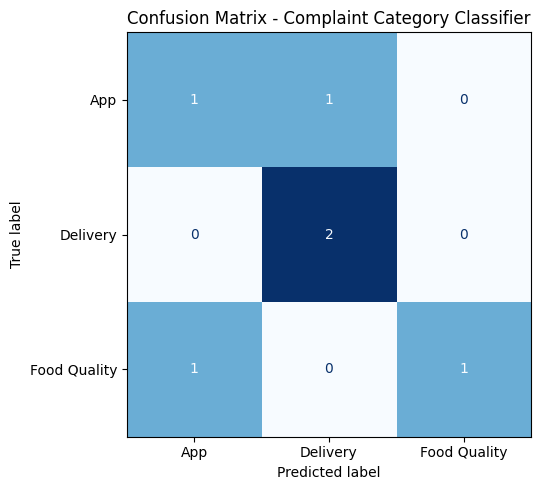

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Complaint Category Classifier")
plt.tight_layout()
plt.show()

## Notes

- With only ~25 examples total and 5 held out for testing, results can be noisy — this is a small demo dataset, not a production-scale training set. For a more robust model, aim for hundreds of labelled examples per class.
- `stratify=y` was used in the train/test split to preserve class proportions across train and test sets.
- Since the dataset is small, some classes may end up with very few (or zero) test examples for a given run — increasing dataset size or using cross-validation would give more reliable metrics in practice.